## Import libraries

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [ ]:
df = pd.read_csv('../data/cleaned/chicago_crimes_cleaned.csv')

In [4]:
df.shape

(7898543, 26)

In [10]:
df[df['date']=='2025-12-29'].tail(1)
# Mondays encoded as day_of_week = 0.

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,x_coordinate,y_coordinate,latitude,longitude,time,month,day,day_of_week,hour
7897529,14069151,JJ538729,2025-12-29,054XX S FAIRFIELD AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE - YARD (FRONT / BACK),True,False,...,2026-01-06T15:42:54.000,1158967.0,1868427.0,41.794691,-87.692606,23:56:00,12,29,0,23


# Encoding cyclical date/time variables

In [12]:
# Convert time to decimal hours: hour + minute/60 + second/3600
td = pd.to_timedelta(df['time'].astype(str))
df['time_decimal'] = td.dt.seconds / 3600

# Convert time to cyclical (using sin)
df['time_cyclical'] = np.sin(2 * np.pi * df['time_decimal'] / 24)


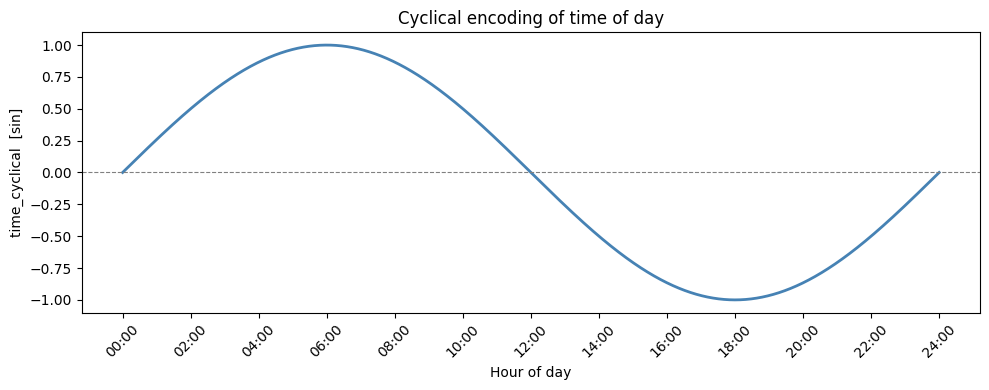

In [19]:
# Plot the sine encoding: x = hour of day, y = time_cyclical
time_mapping = (df[['time_decimal', 'time_cyclical']]
                .drop_duplicates()
                .sort_values('time_decimal'))

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time_mapping['time_decimal'], time_mapping['time_cyclical'],
        color='steelblue', linewidth=2)

ax.set_xlabel('Hour of day')
ax.set_ylabel('time_cyclical  [sin]')
ax.set_title('Cyclical encoding of time of day')
ax.set_xticks(range(0, 25, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)], rotation=45)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
# Convert date to decimal: (month - 1) + (day - 1) / days_in_month
# dt.days_in_month accounts for leap years automatically (e.g. Feb = 28 or 29)

df['date'] = pd.to_datetime(df['date'])

df['date_decimal'] = (
    (date.dt.month - 1) +
    (date.dt.day - 1) / date.dt.days_in_month
)

# Convert date to cyclical (using sin)
df['date_cyclical'] = np.sin(2 * np.pi * df['date_decimal'] / 12)

In [18]:
# Convert day of the week to cyclical

df['dow_cyclical'] = np.sin(2 * np.pi * df['day_of_week'] / 6)

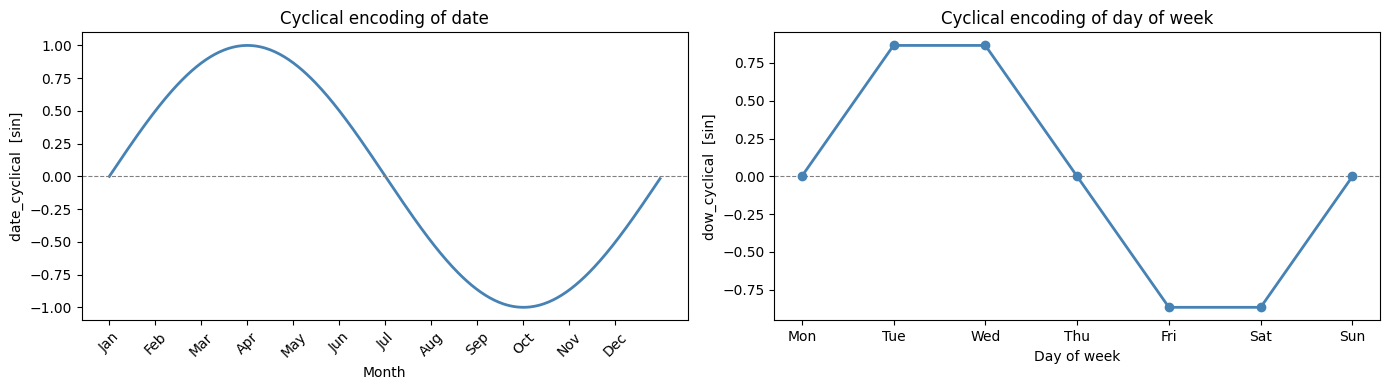

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── date_cyclical ─────────────────────────────────────────────────────────────
date_mapping = (df[['date_decimal', 'date_cyclical']]
                .drop_duplicates()
                .sort_values('date_decimal'))

axes[0].plot(date_mapping['date_decimal'], date_mapping['date_cyclical'],
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('date_cyclical  [sin]')
axes[0].set_title('Cyclical encoding of date')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')

# ── dow_cyclical ──────────────────────────────────────────────────────────────
dow_mapping = (df[['day_of_week', 'dow_cyclical']]
               .drop_duplicates()
               .sort_values('day_of_week'))

axes[1].plot(dow_mapping['day_of_week'], dow_mapping['dow_cyclical'],
             color='steelblue', linewidth=2)
axes[1].scatter(dow_mapping['day_of_week'], dow_mapping['dow_cyclical'],
                color='steelblue', zorder=5)
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('dow_cyclical  [sin]')
axes[1].set_title('Cyclical encoding of day of week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


# Some graphs

In [7]:
## LOOK AT THIS:

# --- Hello -----------------------
total_cases_per_district_per_year = df.groupby(['district', 'year']).agg(total_cases = ('case_number', 'nunique'))

arrest_in_case = df.groupby('case_number').agg(arrests = ('arrest', 'sum'))

columns_of_interest=['year', 'district', 'case_number']
df_cols = df[columns_of_interest].drop_duplicates()

df_graph1 = pd.merge(df_cols, arrest_in_case, on='case_number', how='left')
df_graph1['had_arrest'] = np.where(
    df_graph1['arrests'] > 0, 1, 0)


In [ ]:
# --- Checking if it works:

df_graph1.sort_values(by=['year', 'district', 'case_number'])

# It did :)

,year,district,case_number,arrests,had_arrest
208,2001,1,G000043,0,0
374,2001,1,G000058,1,1
388,2001,1,G000225,0,0
569,2001,1,G000285,0,0
660,2001,1,G000463,1,1
...,...,...,...,...,...
8277864,2025,31,JJ172679,1,1
8300106,2025,31,JJ213829,0,0
8321074,2025,31,JJ252525,0,0
8325091,2025,31,JJ260308,1,1


In [ ]:
## Final table

df_graph1 = df_graph1.groupby(['year','district']).agg(total_cases = ('case_number','count'),
                                                       total_atleastonearrest = ('had_arrest', 'sum'))
df_graph1['had_arrest_rate'] = df_graph1['total_atleastonearrest'] / df_graph1['total_cases']
df_graph1 = df_graph1.reset_index()

total_cases  total_atleastonearrest  had_arrest_rate
year district                                                      
2001 1               14863                    4419         0.297315
     2               35413                   13345         0.376839
     3               24318                    6313         0.259602
     4               25119                    5746         0.228751
     5               20005                    4994         0.249638
...                    ...                     ...              ...
2025 20               4984                     605         0.121388
     22               7612                     994         0.130583
     24               7591                    1121         0.147675
     25              11527                    2236         0.193979
     31                 12                       2         0.166667

[576 rows x 3 columns]

I want to graph, for each district, the proportion of cases in which at least one arrest ocurred per year:

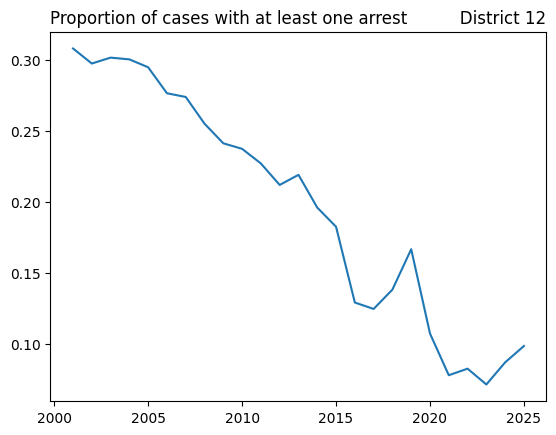

In [66]:
# As it is now, you need to change the district manually:

plt.plot(df_graph1['year'][df_graph1['district']==12], df_graph1['had_arrest_rate'][df_graph1['district']==12])
plt.title('Proportion of cases with at least one arrest\
          District 12')
plt.show()

Put differently, I now graph, for each year, the proportion of cases that involved at least one arrest per district.

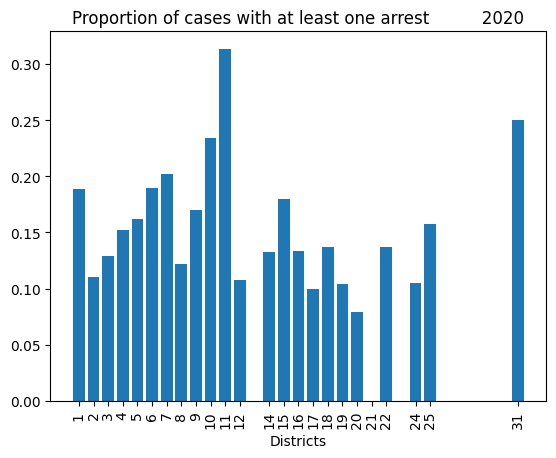

In [65]:
# As it is now, you need to change the year manually:

plt.bar(df_graph1['district'][df_graph1['year']==2020], df_graph1['had_arrest_rate'][df_graph1['year']==2020])
plt.title('Proportion of cases with at least one arrest\
          2020')
plt.xlabel('Districts')
plt.xticks(ticks = df_graph1['district'].unique(), rotation = 90)
plt.show()